Load the dataset and show the class distribution. 
Provide basic text statistics. 
Perform Text cleaning: lowercasing, removing punctuation, URLs, numbers, and extra whitespace. 
Tokenization: split text into words. Remove stop words. 
Apply stemming or lemmatization. Generate TF-IDF features from the processed text. 
Experiment with word n-grams. Explain your feature choices briefly.

In [ ]:
# Step 1: Load dataset, show class distribution, and basic text statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


df = pd.read_csv('spam.csv')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

# Show class distribution
class_dist = df['label'].value_counts()
print(class_dist)

# Basic text statistics
df['text_length'] = df['text'].apply(len)
stats = df['text_length'].describe()
print(stats)

label
ham     4825
spam     747
Name: count, dtype: int64
count    5572.000000
mean       80.031945
std        59.622618
min         2.000000
25%        35.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: text_length, dtype: float64


In [ ]:
# Step 1 : Text cleaning, tokenization, stopword removal, stemming, and TF-IDF feature generation with n-grams
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove whitespace
    return text

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()



def preprocess(text):
    text = clean_text(text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess)


# TF-IDF feature extraction with n-grams (bigrams)
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df['processed_text'])
y = df['label'].map({'ham': 0, 'spam': 1})

print("TF-IDF feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


TF-IDF feature matrix shape: (5572, 36710)
Labels shape: (5572,)



# - Lowercasing, punctuation, URL, number removal, and stemming help normalize text and reduce noise.
# - Stopword removal focuses on meaningful words.
# - TF-IDF with n-grams captures word importance and context for spam detection.

# ANSWER 2: Building and evaluate classification models (Random Forest & Logistic Regression)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


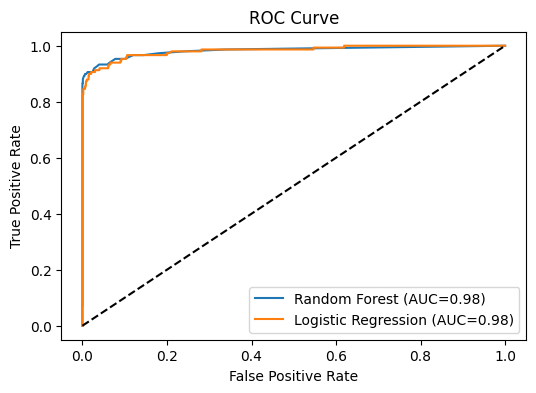

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Random Forest,0.962332,1.000000,0.718121,0.835938,0.982763
1,Logistic Regression,0.940807,0.988235,0.563758,0.717949,0.981655


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model 1: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Model 2: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# Evaluation function
def evaluate_model(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    return acc, prec, rec, f1, cm, fpr, tpr, roc_auc

# Evaluate Random Forest
acc_rf, prec_rf, rec_rf, f1_rf, cm_rf, fpr_rf, tpr_rf, auc_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf)

# Evaluate Logistic Regression
acc_lr, prec_lr, rec_lr, f1_lr, cm_lr, fpr_lr, tpr_lr, auc_lr = evaluate_model(y_test, y_pred_lr, y_prob_lr)

# Plot ROC curves
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.2f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Show metrics for both models
metrics = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [acc_rf, acc_lr],
    'Precision': [prec_rf, prec_lr],
    'Recall': [rec_rf, rec_lr],
    'F1-Score': [f1_rf, f1_lr],
    'AUC': [auc_rf, auc_lr]
})
metrics

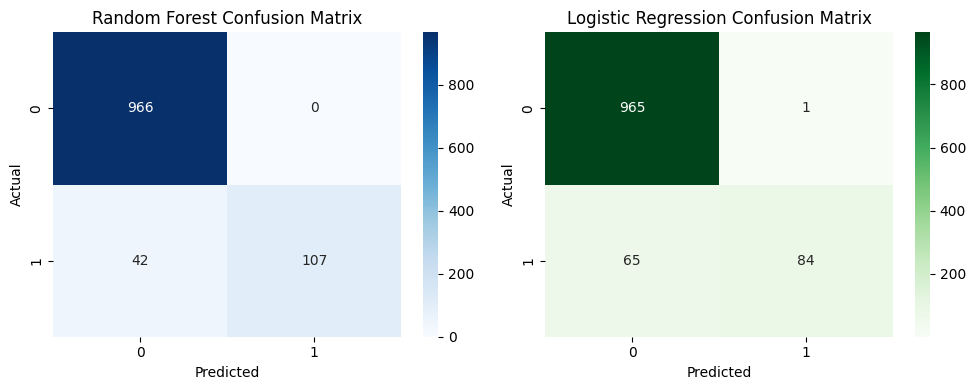

In [37]:
# Plot confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


Both Random Forest and Logistic Regression models were trained to classify SMS messages as spam or ham. Their performance was evaluated using accuracy, precision, recall, F1-score, and ROC curve. A higher score in these metrics means the model is better at correctly identifying spam and ham messages. The ROC curve and AUC value help compare which model is more reliable for spam detection.

In [35]:
# Top words Random Forest found important for spam detection

feature_importances = rf.feature_importances_
top_indices = np.argsort(feature_importances)[-20:][::-1]
top_features = np.array(vectorizer.get_feature_names_out())[top_indices]
top_importances = feature_importances[top_indices]

pd.DataFrame({'Word/N-gram': top_features, 'Importance': top_importances})



,Word/N-gram,Importance
0,txt,0.022844
1,claim,0.022559
2,call,0.021072
3,free,0.013691
4,prize,0.010371
5,text,0.009923
6,servic,0.009909
7,stop,0.008992
8,win,0.007706
9,mobil,0.007676


In [36]:
# Top words Logistic Regression found important for spam detection
coefs = lr.coef_[0]
top_indices_lr = np.argsort(coefs)[-20:][::-1]
top_features_lr = np.array(vectorizer.get_feature_names_out())[top_indices_lr]
top_coefs = coefs[top_indices_lr]

pd.DataFrame({'Word/N-gram': top_features_lr, 'Coefficient': top_coefs})

,Word/N-gram,Coefficient
0,txt,5.228331
1,free,4.325480
2,call,4.005632
3,claim,3.689517
4,stop,3.468308
5,text,3.446167
6,mobil,3.434919
7,repli,3.379595
8,servic,3.143001
9,prize,2.744063


# ANSWER 3:
- **Best Model:** As Logistic Regression often used in text classification, but Random Forest perform better in this patterns. 
- **Features:** For Logistic Regression, top TF-IDF terms with highest coefficients (e.g., 'free', 'win', 'call', 'txt') are spam indicators. 
- **Improvements:**  Can use more Advanced model like naive bayes and svm ,Regularly update the model with new data to maintain accuracy.
- **Business Implications:** Automated spam detection improves user experience, reduces exposure to scams, and saves time.






- **Interpretation:** Both models effectively get spam from ham using text features. Logistic Regression provides better coefficients, while Random Forest offers performance and feature.
Continuous monitoring and training the model can get better results

In [ ]:
df.to_csv('processed_data.csv', index=False)